In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import loadmat
from PIL import Image

In [2]:
from helper_functions.helper_functions import Interpolate
resize = Interpolate(size=512)

In [3]:
bscan_our=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training_bscan/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001_row_0250.npy")
mask_our=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/training_mask/2026_03_26_cfrp_multiple_fbh_gauss_heat_5s_30s_45W_multiple_fbh_001_row_0250.npy")

In [7]:
bscan_exp=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/bscan_splits/val_surface_1p0mm_test_surface_2p0mm/training_data/R_002_row_0108.npy")
mask_exp=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/bscan_splits/val_surface_1p0mm_test_surface_2p0mm/training_mask/R_002_row_0108.npy")

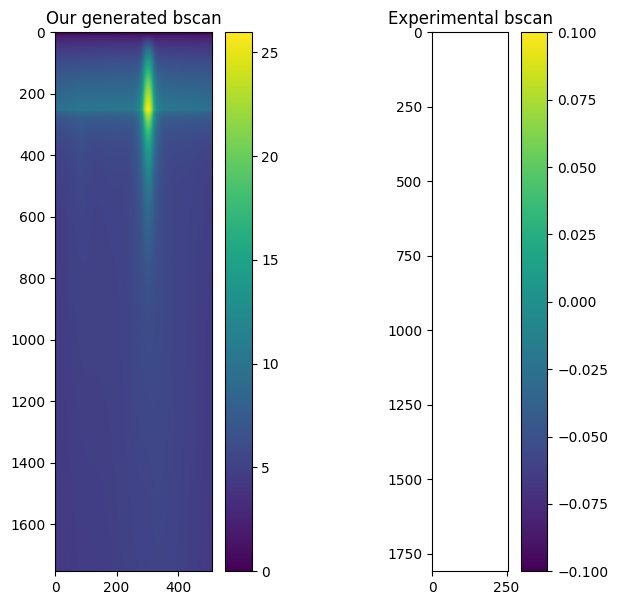

In [9]:
plt.figure(figsize=(7,7))
plt.subplot(1,2,1)
plt.imshow(bscan_our)
plt.title("Our generated bscan")
plt.colorbar()


plt.subplot(1,2,2)
plt.imshow(bscan_exp[:,:])
plt.title("Experimental bscan")
plt.colorbar()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

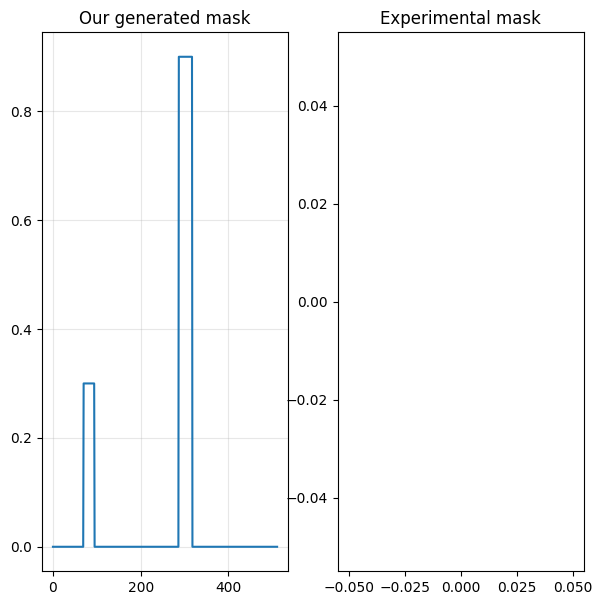

In [10]:
plt.figure(figsize=(7,7))
plt.subplot(1,2,1)
plt.plot(mask_our)
plt.title("Our generated mask")
plt.grid(alpha=0.3)


plt.subplot(1,2,2)
plt.plot(bscan_exp[1:,:])
plt.title("Experimental mask")
plt.colorbar()

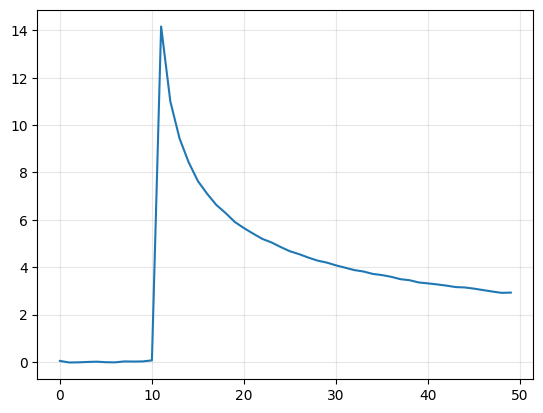

In [49]:
rb_data=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/open_source_data_npz_rb_2/R_004.npz",allow_pickle=True)
plt.plot(rb_data['data'][:50,160,125])
plt.grid(alpha=0.3)

In [31]:
experiment=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/open_source_data_npz_rb/R_002.npz",allow_pickle=True)
data=experiment['data']
mask=experiment['mask']

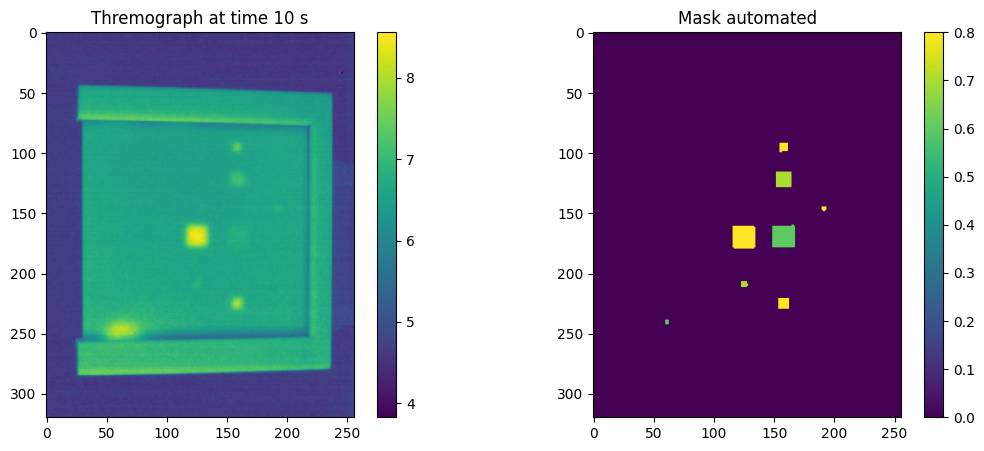

In [32]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
plt.imshow(data[100])
plt.title('Thremograph at time 10 s')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(mask)
plt.title('Mask automated')
plt.colorbar()

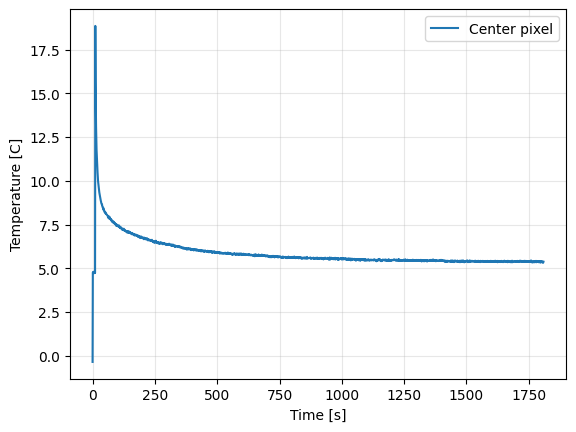

In [33]:
T,H,W,=data.shape
H_c=H//2
W_c=W//2
time=np.arange(T)*0.1
plt.plot(data[:,H_c,W_c],label='Center pixel')
plt.grid(alpha=0.3)
plt.xlabel('Time [s]')
plt.ylabel('Temperature [C]')
plt.legend()

In [16]:
import os
import glob
import numpy as np
from PIL import Image

# Mapping from mask pixel values to distance from measured surface
PIXEL_TO_DEPTH_MM = {
    0: "sound / no defect",
    51: 0.5,
    102: 1.0,
    153: 1.5,
    204: 2.0,
    255: 2.5,
}


def inspect_png_masks(mask_folder):
    """
    Go through all PNG masks in folder and print unique pixel values
    together with corresponding defect burial depths.

    Parameters
    ----------
    mask_folder : str
        Path to folder containing grayscale PNG masks.
    """

    mask_paths = sorted(glob.glob(os.path.join(mask_folder, "*.png")))

    if len(mask_paths) == 0:
        print(f"No PNG masks found in: {mask_folder}")
        return

    for path in mask_paths:
        img = Image.open(path).convert("L")  # force grayscale
        mask = np.array(img)

        unique_values = np.unique(mask)

        print("=" * 80)
        print(f"Mask: {os.path.basename(path)}")
        print(f"Unique pixel values: {unique_values.tolist()}")

        print("Depths present:")
        for value in unique_values:
            value = int(value)

            if value in PIXEL_TO_DEPTH_MM:
                depth = PIXEL_TO_DEPTH_MM[value]

                if value == 0:
                    print(f"  pixel {value:3d} -> {depth}")
                else:
                    print(f"  pixel {value:3d} -> {depth:.1f} mm")
            else:
                print(f"  pixel {value:3d} -> UNKNOWN VALUE")

        print()


# Example usage
mask_folder = r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/labels/automated_mask"
inspect_png_masks(mask_folder)

Mask: R_002.png
Unique pixel values: [0, 102, 153, 204]
Depths present:
  pixel   0 -> sound / no defect
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm

Mask: R_003.png
Unique pixel values: [0, 51, 102, 153, 204]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm

Mask: R_004.png
Unique pixel values: [0, 51, 102, 153, 204, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm
  pixel 255 -> 2.5 mm

Mask: R_005.png
Unique pixel values: [0, 51, 102, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 255 -> 2.5 mm

Mask: R_006.png
Unique pixel values: [0, 51, 102, 153, 204, 255]
Depths present:
  pixel   0 -> sound / no defect
  pixel  51 -> 0.5 mm
  pixel 102 -> 1.0 mm
  pixel 153 -> 1.5 mm
  pixel 204 -> 2.0 mm
  pixel 255 -> 2.5 mm

Mask: R_0

In [28]:
import os
import glob
import numpy as np
from PIL import Image
from collections import defaultdict

PIXEL_TO_DEPTH_MM = {
    0: 0.0,
    51: 0.5,
    102: 1.0,
    153: 1.5,
    204: 2.0,
    255: 2.5,
}

DEPTH_TO_PIXEL = {
    0.5: 51,
    1.0: 102,
    1.5: 153,
    2.0: 204,
    2.5: 255,
}


def analyze_column_bscan_split_strict_val(
    mask_folder,
    val_depth_mm,
    test_depth_mm,
    direction="columns",
):
    """
    Analyze B-scan split where:

    Train:
        columns containing only train depths and/or background.

    Validation:
        columns containing validation depth only, possibly with background,
        but no train depths and no test depth.

    Test:
        columns containing test depth.
        Test columns may be mixed with other depths because final metrics
        can be depth-aware.

    Background:
        columns containing only pixel value 0.
    """

    if val_depth_mm == test_depth_mm:
        raise ValueError("Validation and test depth must be different.")

    val_pixel = DEPTH_TO_PIXEL[val_depth_mm]
    test_pixel = DEPTH_TO_PIXEL[test_depth_mm]

    all_defect_pixels = set(DEPTH_TO_PIXEL.values())
    forbidden_for_train = {val_pixel, test_pixel}
    train_pixels = all_defect_pixels - forbidden_for_train

    mask_paths = sorted(glob.glob(os.path.join(mask_folder, "*.png")))

    if len(mask_paths) == 0:
        raise FileNotFoundError(f"No PNG masks found in: {mask_folder}")

    global_counts = defaultdict(int)
    per_file_results = []

    for path in mask_paths:
        mask = np.array(Image.open(path).convert("L"))

        if direction == "columns":
            n_bscans = mask.shape[1]
            slices = [mask[:, i] for i in range(mask.shape[1])]
        elif direction == "rows":
            n_bscans = mask.shape[0]
            slices = [mask[i, :] for i in range(mask.shape[0])]
        else:
            raise ValueError("direction must be 'columns' or 'rows'.")

        file_counts = defaultdict(int)

        for idx, bscan_mask in enumerate(slices):
            unique_values = set(np.unique(bscan_mask).astype(int).tolist())
            defect_values = unique_values - {0}

            is_background = len(defect_values) == 0

            has_val = val_pixel in defect_values
            has_test = test_pixel in defect_values
            has_train_depth = len(defect_values & train_pixels) > 0

            contains_only_train_depths = (
                len(defect_values) > 0
                and defect_values.issubset(train_pixels)
            )

            contains_only_val_depth = (
                defect_values == {val_pixel}
            )

            # Split assignment
            if is_background:
                split = "background_train_candidate"

            elif contains_only_train_depths:
                split = "train"

            elif contains_only_val_depth:
                split = "val_strict"

            elif has_test:
                split = "test_mixed_allowed"

            elif has_val and has_train_depth:
                split = "discarded_val_train_mixed"

            elif has_val and has_test:
                split = "discarded_val_test_mixed"

            else:
                split = "discarded_other"

            file_counts[split] += 1
            global_counts[split] += 1

        per_file_results.append(
            {
                "file": os.path.basename(path),
                "n_bscans": n_bscans,
                "train": file_counts["train"],
                "val_strict": file_counts["val_strict"],
                "test_mixed_allowed": file_counts["test_mixed_allowed"],
                "background": file_counts["background_train_candidate"],
                "discarded_val_train_mixed": file_counts["discarded_val_train_mixed"],
                "discarded_val_test_mixed": file_counts["discarded_val_test_mixed"],
                "discarded_other": file_counts["discarded_other"],
            }
        )

    print("=" * 100)
    print(f"STRICT VALIDATION split analysis for B-scans extracted by: {direction}")
    print(f"Validation depth: {val_depth_mm} mm -> pixel {val_pixel}")
    print(f"Test depth:       {test_depth_mm} mm -> pixel {test_pixel}")
    print(f"Train depths:     {[PIXEL_TO_DEPTH_MM[p] for p in sorted(train_pixels)]} mm")
    print("=" * 100)

    print("\nGLOBAL COUNTS")
    print(f"Train defect B-scans:          {global_counts['train']}")
    print(f"Strict validation B-scans:     {global_counts['val_strict']}")
    print(f"Test B-scans, mixed allowed:   {global_counts['test_mixed_allowed']}")
    print(f"Background train candidates:   {global_counts['background_train_candidate']}")
    print()
    print(f"Discarded val+train mixed:     {global_counts['discarded_val_train_mixed']}")
    print(f"Discarded val+test mixed:      {global_counts['discarded_val_test_mixed']}")
    print(f"Discarded other:               {global_counts['discarded_other']}")

    train_total_with_balanced_bg = (
        global_counts["train"] +
        min(global_counts["train"], global_counts["background_train_candidate"])
    )

    print(f"\nBalanced train size estimate:")
    print(
        f"{global_counts['train']} defect + "
        f"{min(global_counts['train'], global_counts['background_train_candidate'])} background "
        f"= {train_total_with_balanced_bg}"
    )

    print("\nPER FILE COUNTS")
    for r in per_file_results:
        print(
            f"{r['file']:12s} | "
            f"all={r['n_bscans']:4d} | "
            f"train={r['train']:4d} | "
            f"val={r['val_strict']:4d} | "
            f"test={r['test_mixed_allowed']:4d} | "
            f"bg={r['background']:4d} | "
            f"discard_vt={r['discarded_val_train_mixed']:4d}"
        )

    return per_file_results, dict(global_counts)

In [29]:
mask_folder = r"/home/kjaworski/Pulpit/Temporal_thermal_imaging/Open_Source_Dataset/archive/labels/automated_mask"

results, counts = analyze_column_bscan_split_strict_val(
    mask_folder=mask_folder,
    val_depth_mm=1.0,
    test_depth_mm=2.0,
    direction="columns",
)

STRICT VALIDATION split analysis for B-scans extracted by: columns
Validation depth: 1.0 mm -> pixel 102
Test depth:       2.0 mm -> pixel 204
Train depths:     [0.5, 1.5, 2.5] mm

GLOBAL COUNTS
Train defect B-scans:          1245
Strict validation B-scans:     489
Test B-scans, mixed allowed:   610
Background train candidates:   9567

Discarded val+train mixed:     249
Discarded val+test mixed:      0
Discarded other:               0

Balanced train size estimate:
1245 defect + 1245 background = 2490

PER FILE COUNTS
R_002.png    | all= 320 | train=  18 | val=  22 | test=  23 | bg= 257 | discard_vt=   0
R_003.png    | all= 320 | train=  21 | val=   6 | test=  25 | bg= 261 | discard_vt=   7
R_004.png    | all= 320 | train=  35 | val=  17 | test=  43 | bg= 207 | discard_vt=  18
R_005.png    | all= 320 | train=  13 | val=   4 | test=   0 | bg= 303 | discard_vt=   0
R_006.png    | all= 320 | train=  36 | val=  16 | test=  40 | bg= 214 | discard_vt=  14
R_007.png    | all= 320 | train=  27

In [30]:
depths = [0.5, 1.0, 1.5, 2.0, 2.5]

all_split_counts = []

for test_depth in depths:
    for val_depth in depths:
        if val_depth == test_depth:
            continue

        _, counts = analyze_column_bscan_split_strict_val(
            mask_folder=mask_folder,
            val_depth_mm=val_depth,
            test_depth_mm=test_depth,
            direction="columns",
        )

        train = counts.get("train", 0)
        bg = counts.get("background_train_candidate", 0)

        all_split_counts.append({
            "val_depth": val_depth,
            "test_depth": test_depth,
            "train": train,
            "val_strict": counts.get("val_strict", 0),
            "test_mixed_allowed": counts.get("test_mixed_allowed", 0),
            "background": bg,
            "balanced_train_total": train + min(train, bg),
            "discarded_val_train_mixed": counts.get("discarded_val_train_mixed", 0),
            "discarded_val_test_mixed": counts.get("discarded_val_test_mixed", 0),
        })


print("\nSUMMARY OF ALL 20 STRICT-VALIDATION SPLITS")
print("=" * 110)

for s in all_split_counts:
    print(
        f"val={s['val_depth']:.1f} mm | "
        f"test={s['test_depth']:.1f} mm | "
        f"train={s['train']:5d} | "
        f"val_strict={s['val_strict']:5d} | "
        f"test={s['test_mixed_allowed']:5d} | "
        f"bg={s['background']:5d} | "
        f"balanced_train={s['balanced_train_total']:5d} | "
        f"discard_val_train={s['discarded_val_train_mixed']:5d}"
    )

STRICT VALIDATION split analysis for B-scans extracted by: columns
Validation depth: 1.0 mm -> pixel 102
Test depth:       0.5 mm -> pixel 51
Train depths:     [1.5, 2.0, 2.5] mm

GLOBAL COUNTS
Train defect B-scans:          1032
Strict validation B-scans:     489
Test B-scans, mixed allowed:   775
Background train candidates:   9567

Discarded val+train mixed:     297
Discarded val+test mixed:      0
Discarded other:               0

Balanced train size estimate:
1032 defect + 1032 background = 2064

PER FILE COUNTS
R_002.png    | all= 320 | train=  23 | val=  22 | test=   0 | bg= 257 | discard_vt=  18
R_003.png    | all= 320 | train=  25 | val=   6 | test=  28 | bg= 261 | discard_vt=   0
R_004.png    | all= 320 | train=  51 | val=  17 | test=  23 | bg= 207 | discard_vt=  22
R_005.png    | all= 320 | train=  10 | val=   4 | test=   3 | bg= 303 | discard_vt=   0
R_006.png    | all= 320 | train=  12 | val=  16 | test=  59 | bg= 214 | discard_vt=  19
R_007.png    | all= 320 | train=  24 